In [1]:
# RRCP (08/08/2026):Interpretación de K-Means para Jugadores
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import ipywidgets as widgets
from IPython.display import display

In [2]:
# Cargar Datos
df_jugadores = pd.read_csv("../data/jugadores_cebollitas.csv")
df_jugadores.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   jugador_id             20 non-null     int64  
 1   nombre                 20 non-null     str    
 2   posición               20 non-null     str    
 3   edad                   20 non-null     int64  
 4   partidos_jugados       20 non-null     int64  
 5   goles                  20 non-null     int64  
 6   asistencias            20 non-null     int64  
 7   pases_completados (%)  20 non-null     float64
 8   tiros_al_arco          20 non-null     int64  
 9   precisión_tiros (%)    20 non-null     float64
 10  minutos_jugados        20 non-null     int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 1.8 KB


In [3]:
# Creación del Cluster
X = df_jugadores[['goles','asistencias','pases_completados (%)','tiros_al_arco']]
kmeans = KMeans(n_clusters = 3, random_state = 42) # Instancia de KMeans con 3 clusters.
df_jugadores['cluster'] = kmeans.fit_predict(X) # Asigna centroides al azar y asigna jugadores.

In [ ]:
columnas_numericas = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']
cluster_profiles = df_jugadores.groupby('cluster')[columnas_numericas].mean() # Calcula el perfil medio de cada grupo.
print(cluster_profiles)

         goles  asistencias  pases_completados (%)  tiros_al_arco
cluster                                                          
0          3.6          3.6                  80.04           44.8
1          2.6          4.9                  87.29            3.3
2          2.6          4.4                  78.34            9.0


/tmp/ipykernel_3472/3289101860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


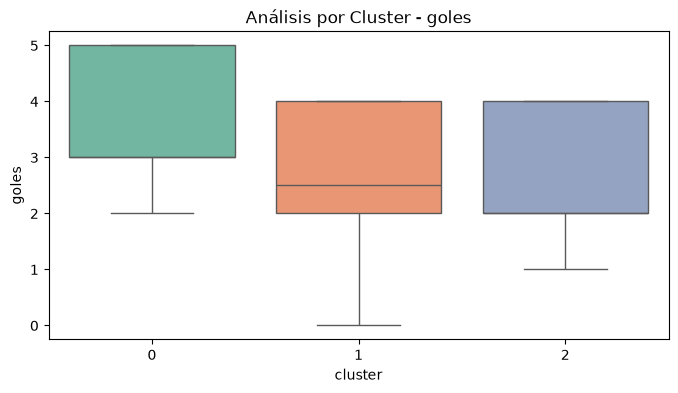

/tmp/ipykernel_3472/3289101860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


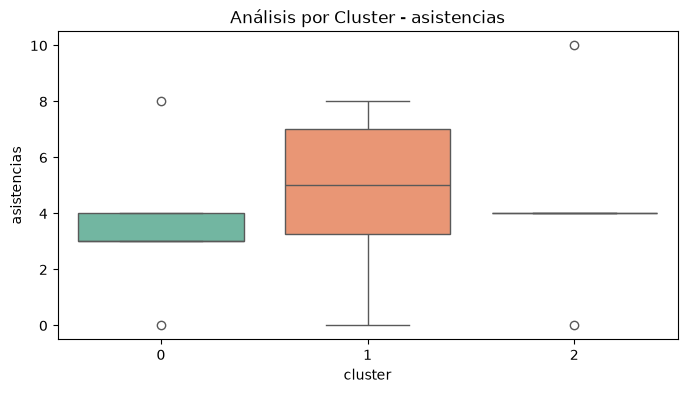

/tmp/ipykernel_3472/3289101860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


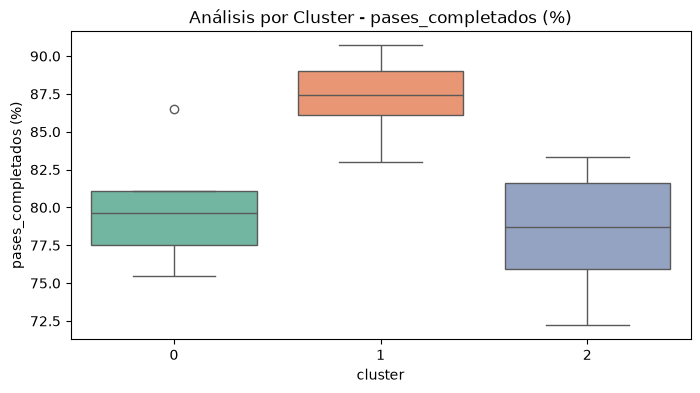

/tmp/ipykernel_3472/3289101860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


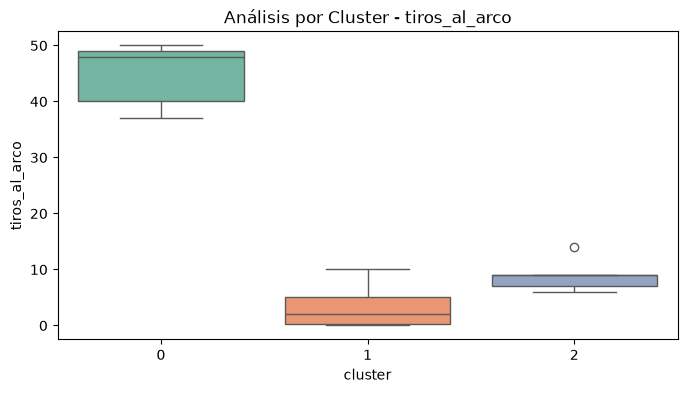

In [ ]:
# Analisis Boxplot del cluster.
features = ['goles','asistencias','pases_completados (%)', 'tiros_al_arco']

for feature in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')
    plt.title(f'Análisis por Cluster - {feature}')
    plt.show()

## INTERPRETACIÓN
### BOXPLOT 1: GOLES
- Cluster 0: Meten entre 3 y 5 goles.
- Cluster 1: Meten entre 2 y 4 goles, la mitad mete de 2.5 goles para arriba y para abajo (mediana).
- Cluster 2: Meten entre 2 y 4 goles.
### BOXPLOT 2: ASISTENCIAS
- Cluster 0: Asisten entre 2.5 y 4 partidos.
- Cluster 1: Asisten entre 3 y 7 partidos, la mitad asiste de 5 partidos para arriba y para abajo (mediana).
- Cluster 2: Asisten a 4 partidos.
### BOXPLOT 3: PASES COMPLETADOS
- Cluster 0: Entre 75% y 81.5% pases copletados. La mitad completa el 80% de los pases (mediana).
- Cluster 1: Entre 86.5% y 88.5% pases copletados. La mitad completa el 87.5% de los pases (mediana).
- Cluster 2: Entre 86.5% y 81.5% pases copletados. La mitad completa el 79.5% de los pases (mediana).
### BOXPLOT 4: TIROS AL ARCO
- Cluster 0: Entre 40 y 59 tiros al arco. La mitad da 48 tiros al arco (mediana).
- Cluster 1: Entre 1 y 5 tiros al arco. La mitad da 3 tiros al arco (mediana).
- Cluster 2: Entre 8 y 9 tiros al arco.

In [6]:
# Dropdown interactivo
cluster_selector = widgets.Dropdown(
    options = sorted(df_jugadores['cluster'].unique()),
    description = 'Cluster:'
)

# Función de Despliegue
def mostrar_jugadores(cluster):
    jugadores = df_jugadores[df_jugadores['cluster'] == cluster]
    display(jugadores[['nombre','goles','asistencias','pases_completados (%)', 'tiros_al_arco']])

# Activar widgets
widgets.interactive(mostrar_jugadores, cluster = cluster_selector)

interactive(children=(Dropdown(description='Cluster:', options=(np.int32(0), np.int32(1), np.int32(2)), value=…